In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

file = DATA_DIR / "Academic_Project_Similarity_Synthetic_Dataset.xlsx"

projects = pd.read_excel(
    file,
    sheet_name="Projects"
)

pairs = pd.read_excel(
    file,
    sheet_name="SimilarityPairs"
)

print("Projects:", projects.shape)
print("Pairs:", pairs.shape)

Projects: (600, 16)
Pairs: (3000, 8)


In [5]:
text_columns = [
    "project_title",
    "abstract",
    "problem_statement",
    "objectives",
    "proposed_methodology",
    "dataset",
    "algorithm_model",
    "technology_tools"
]

projects["combined_text"] = (
    projects[text_columns]
    .fillna("")
    .astype(str)
    .agg(" ".join, axis=1)
)

In [6]:
print(projects[["project_id", "combined_text"]].head(2))

  project_id                                      combined_text
0   SYN-0001  Prototype Crop Disease Detection Using CNN Thi...
1   SYN-0002  Web-Based Network Intrusion Detection Using Ra...


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1
)

tfidf_matrix = vectorizer.fit_transform(
    projects["combined_text"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (600, 1485)


In [8]:
project_to_index = {
    project_id: index
    for index, project_id
    in enumerate(projects["project_id"])
}

In [10]:
print(project_to_index["SYN-0051"])

50


In [11]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_scores = []

for _, row in pairs.iterrows():

    idx_a = project_to_index[row["project_A_id"]]
    idx_b = project_to_index[row["project_B_id"]]

    vector_a = tfidf_matrix[idx_a]
    vector_b = tfidf_matrix[idx_b]

    score = cosine_similarity(
        vector_a,
        vector_b
    )[0][0]

    tfidf_scores.append(score)

pairs["tfidf_similarity"] = tfidf_scores

In [12]:
display(
    pairs[
        [
            "project_A_id",
            "project_B_id",
            "expert_similarity_label",
            "similarity_category",
            "tfidf_similarity"
        ]
    ].head(10)
)

,project_A_id,project_B_id,expert_similarity_label,similarity_category,tfidf_similarity
0,SYN-0033,SYN-0119,0,Not Similar,0.128376
1,SYN-0368,SYN-0009,0,Not Similar,0.080528
2,SYN-0309,SYN-0337,0,Not Similar,0.095971
3,SYN-0510,SYN-0295,0,Not Similar,0.095362
4,SYN-0356,SYN-0485,3,Highly Similar,0.731195
5,SYN-0226,SYN-0330,3,Highly Similar,0.755297
6,SYN-0132,SYN-0496,0,Not Similar,0.074550
7,SYN-0363,SYN-0144,0,Not Similar,0.084293
8,SYN-0013,SYN-0479,3,Highly Similar,0.887246
9,SYN-0553,SYN-0375,0,Not Similar,0.119752


In [13]:
label_analysis = (
    pairs
    .groupby("expert_similarity_label")["tfidf_similarity"]
    .agg(["count", "mean", "median", "min", "max"])
)

display(label_analysis)

,count,mean,median,min,max
expert_similarity_label,,,,,
0,1336,0.116242,0.098085,0.051908,0.541653
1,334,0.448047,0.311375,0.057888,0.957908
2,514,0.783579,0.813121,0.307397,0.983551
3,581,0.786333,0.814968,0.311301,1.000000
4,235,0.778707,0.816566,0.303810,0.955258


In [14]:
comparison = (
    pairs
    .groupby("expert_similarity_label")
    [
        [
            "baseline_lexical_overlap_proxy",
            "tfidf_similarity"
        ]
    ]
    .mean()
)

display(comparison)

,baseline_lexical_overlap_proxy,tfidf_similarity
expert_similarity_label,,
0,0.736859,0.116242
1,0.830715,0.448047
2,0.929809,0.783579
3,0.929891,0.786333
4,0.926843,0.778707


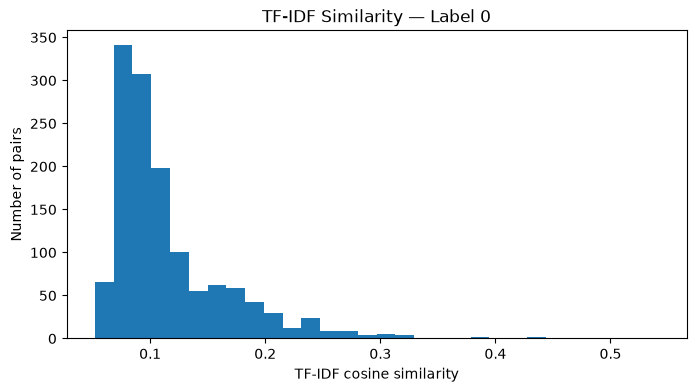

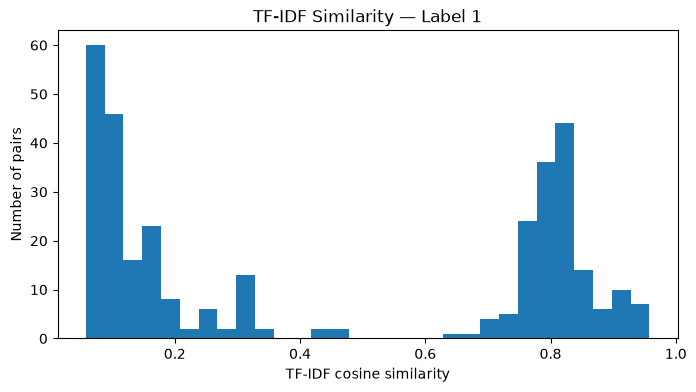

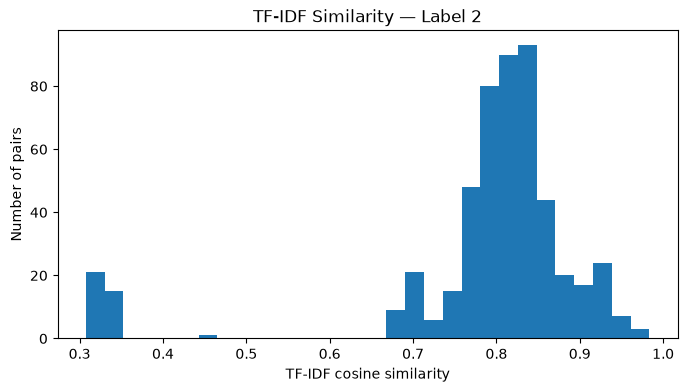

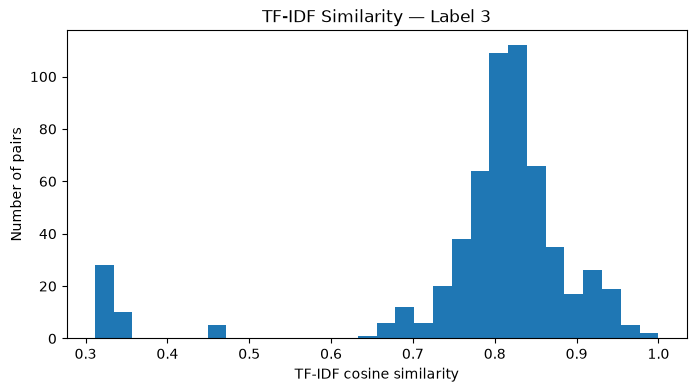

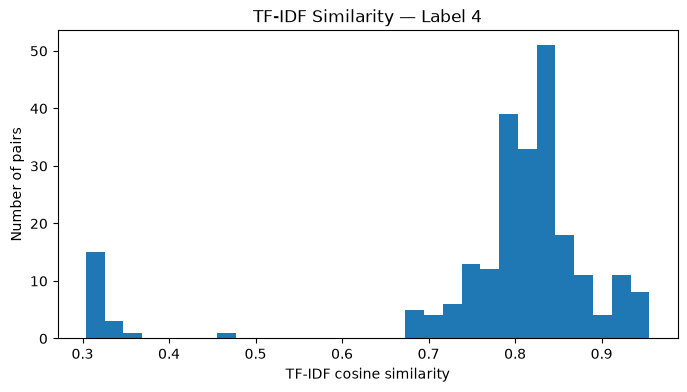

In [15]:
import matplotlib.pyplot as plt

for label in sorted(pairs["expert_similarity_label"].unique()):

    subset = pairs[
        pairs["expert_similarity_label"] == label
    ]

    plt.figure(figsize=(8, 4))
    plt.hist(subset["tfidf_similarity"], bins=30)
    plt.title(f"TF-IDF Similarity — Label {label}")
    plt.xlabel("TF-IDF cosine similarity")
    plt.ylabel("Number of pairs")
    plt.show()

<Figure size 900x500 with 0 Axes>

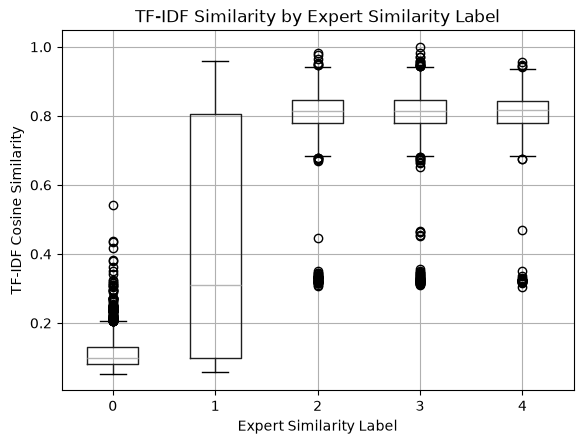

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

pairs.boxplot(
    column="tfidf_similarity",
    by="expert_similarity_label"
)

plt.title("TF-IDF Similarity by Expert Similarity Label")
plt.suptitle("")
plt.xlabel("Expert Similarity Label")
plt.ylabel("TF-IDF Cosine Similarity")
plt.show()

In [17]:
print(
    pairs[
        ["expert_similarity_label", "tfidf_similarity"]
    ].corr()
)

                         expert_similarity_label  tfidf_similarity
expert_similarity_label                 1.000000          0.842205
tfidf_similarity                        0.842205          1.000000


In [20]:
from scipy.stats import spearmanr

correlation, p_value = spearmanr(
    pairs["expert_similarity_label"],
    pairs["tfidf_similarity"]
)

print("Spearman correlation:", correlation)
print("p-value:", p_value)

Spearman correlation: 0.7870861255848627
p-value: 0.0


SyntaxError: invalid syntax (3382125404.py, line 1)